# Week 3: Risk Metrics and Portfolio Construction

Builds a reusable risk-metrics module (`src/risk.py`), applies it to the Week 2 factor portfolios, then compares portfolio construction methods.

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
import numpy as np
import pandas as pd

sys.path.append("../../src")
from risk import compute_risk_metrics, infer_periods_per_year, max_drawdown
from factor_utils import performance_table

PORTFOLIOS = "../../data/portfolios"
REPORTS = "../../reports/week3"
os.makedirs(REPORTS, exist_ok=True)

## Task 1: Risk Metrics

`compute_risk_metrics()` in `src/risk.py` reports, for any return series:

| Metric | Definition | Basis |
| --- | --- | --- |
| Annual return (CAGR) | compound growth per year | annualized |
| Annual return (mean) | average periodic return × periods per year | annualized |
| Volatility | std of periodic returns × √(periods per year) | annualized |
| Downside deviation | √mean(min(r − rf, 0)²) × √(periods per year) | annualized |
| Sharpe | annual mean excess return ÷ volatility | annualized |
| Sortino | annual mean excess return ÷ downside deviation | annualized |
| Max drawdown | worst fall from a previous peak | over the full period |
| Calmar | CAGR ÷ \|max drawdown\| | annualized |
| Skewness, excess kurtosis | shape of the periodic return distribution | per period (not annualized) |
| Hit rate | share of periods with a positive return | per period |

**Annualization follows the data's frequency:** daily → 252, monthly → 12, inferred from the dates (the function refuses to guess if the spacing is unclear). Risk-free rate = 0 throughout: correct for the zero-cost long–short, and it keeps every row on the same basis.

### 1.1 Load the Week 2 portfolios
Monthly equal-weight quintile returns (Q1–Q5) and the long–short (Q5 − Q1) for value and momentum, July 2021 – August 2026.

In [2]:
value_ret = pd.read_csv(f"{PORTFOLIOS}/value_quintile_returns.csv", index_col=0, parse_dates=True)
mom_ret = pd.read_csv(f"{PORTFOLIOS}/momentum_quintile_returns.csv", index_col=0, parse_dates=True)
COLS = ["Q1", "Q2", "Q3", "Q4", "Q5", "long_short"]

print("Frequency inferred from the dates:", infer_periods_per_year(value_ret.index), "periods per year (monthly)")
print("Months:", len(value_ret), "|", value_ret.index.min().date(), "to", value_ret.index.max().date())

Frequency inferred from the dates: 12 periods per year (monthly)
Months: 62 | 2021-07-30 to 2026-08-31


### 1.2 Annualization check: daily vs monthly
The same portfolio (equal-weight across all 50 stocks) measured on **daily** and on **monthly** returns. If annualization is right, annual return, volatility, Sharpe and drawdown should come out nearly the same. Shape statistics (skewness, kurtosis) are *not* annualized, so they differ by frequency and must always state it.

In [3]:
prices = pd.read_csv("../../data/raw/prices_2020.csv", parse_dates=["date"])
px = prices.pivot(index="date", columns="ticker", values="adj_close").loc["2021-07-01":"2026-08-31"]
ew_daily = px.pct_change().mean(axis=1).dropna().rename("Equal-weight, daily returns")
ew_monthly = (1 + ew_daily).resample("ME").prod().sub(1).rename("Equal-weight, monthly returns")

freq_check = pd.concat([compute_risk_metrics(ew_daily), compute_risk_metrics(ew_monthly)])
freq_check[["periods_per_year", "n_periods", "ann_return_cagr", "ann_volatility", "sharpe",
            "max_drawdown", "calmar", "skewness", "excess_kurtosis"]].round(3)

,periods_per_year,n_periods,ann_return_cagr,ann_volatility,sharpe,max_drawdown,calmar,skewness,excess_kurtosis
"Equal-weight, daily returns",252,1296,0.245,0.196,1.217,-0.288,0.852,0.157,5.686
"Equal-weight, monthly returns",12,62,0.244,0.193,1.237,-0.278,0.878,-0.191,-0.501


**What goes wrong with the wrong factor:** the same monthly returns annualized as if they were daily.

In [4]:
wrong = compute_risk_metrics(ew_monthly, periods_per_year=252)
right = compute_risk_metrics(ew_monthly)
pd.DataFrame({
    "correct (12 per year)": right[["ann_volatility", "sharpe"]].iloc[0],
    "wrong (252 per year)": wrong[["ann_volatility", "sharpe"]].iloc[0],
}).round(2)

,correct (12 per year),wrong (252 per year)
ann_volatility,0.19,0.88
sharpe,1.24,5.67


### 1.3 Risk summary table: Week 2 quintile portfolios and long–short factors
Monthly returns, annualized with 12. Saved to `reports/week3/risk_summary.csv`.

In [5]:
risk_summary = pd.concat({
    "Value": compute_risk_metrics(value_ret[COLS]),
    "Momentum": compute_risk_metrics(mom_ret[COLS]),
})
risk_summary.to_csv(f"{REPORTS}/risk_summary.csv")

pct = ["ann_return_cagr", "ann_return_mean", "ann_volatility", "downside_deviation", "max_drawdown", "hit_rate"]
ratios = ["sharpe", "sortino", "calmar", "skewness", "excess_kurtosis"]
show = risk_summary[pct + ratios].copy()
show[pct] = (show[pct] * 100).round(1)
show[ratios] = show[ratios].round(2)
show.columns = ["CAGR %", "Mean ann. %", "Vol %", "Downside dev %", "Max DD %", "Hit rate %",
                "Sharpe", "Sortino", "Calmar", "Skew", "Excess kurt"]
show

CAGR %  Mean ann. %  Vol %  Downside dev %  Max DD %  \
Value    Q1            20.2         22.4   28.3            16.7     -43.6   
         Q2            15.6         16.8   21.7            12.0     -29.1   
         Q3            14.5         15.1   17.4             9.8     -16.3   
         Q4            27.1         26.7   23.0            10.3     -25.1   
         Q5            45.2         42.0   30.0            12.2     -20.9   
         long_short    17.6         19.6   26.4            13.9     -38.9   
Momentum Q1            30.9         30.8   27.3            13.8     -30.1   
         Q2             5.7          7.7   20.7            13.9     -39.9   
         Q3            16.6         16.9   17.2            10.5     -31.2   
         Q4            17.5         18.0   19.1            10.4     -23.1   
         Q5            52.4         49.4   38.3            14.8     -23.1   
         long_short    11.9         18.6   38.5            23.7     -42.7   

                     Hit rate %  Sharpe  Sortino  Calmar  Skew  Excess kurt  
Value    Q1                64.5    0.79     1.34    0.46  0.03         0.18  
         Q2                54.8    0.78     1.40    0.54  0.18        -0.47  
         Q3                62.9    0.87     1.54    0.89 -0.05        -0.36  
         Q4                59.7    1.16     2.59    1.08  0.63         0.44  
         Q5                62.9    1.40     3.43    2.16  0.83         1.85  
         long_short        56.5    0.74     1.41    0.45  0.63         0.85  
Momentum Q1                66.1    1.13     2.23    1.03  0.36         0.54  
         Q2                53.2    0.37     0.55    0.14 -0.31         0.46  
         Q3                62.9    0.98     1.61    0.53 -0.48         0.02  
         Q4                59.7    0.94     1.73    0.76  0.11        -0.35  
         Q5                56.5    1.29     3.33    2.27  1.26         3.54  
         long_short        54.8    0.48     0.78    0.28  0.23         2.94

### 1.4 Checks
1. **Consistency with Week 2:** Sharpe, volatility, max drawdown and hit rate must match Week 2's `performance_table` exactly (same data, same basis).
2. **Hand calculation:** Sortino and Calmar for the value long–short, recomputed from the raw monthly returns.

In [6]:
w2 = pd.concat({"Value": performance_table(value_ret), "Momentum": performance_table(mom_ret)})
pairs = {"sharpe": "sharpe_ratio", "ann_volatility": "annualized_volatility", "max_drawdown": "max_drawdown", "hit_rate": "hit_rate"}
max_diff = max((risk_summary[a] - w2[b].astype(float)).abs().max() for a, b in pairs.items())
print(f"Largest difference vs Week 2: {max_diff:.1e}")

r = value_ret["long_short"]
downside = np.sqrt((np.minimum(r, 0) ** 2).mean()) * np.sqrt(12)
sortino_hand = r.mean() * 12 / downside
cagr_hand = (1 + r).prod() ** (12 / len(r)) - 1
calmar_hand = cagr_hand / abs(max_drawdown(r))
print(f"Value long-short Sortino: hand {sortino_hand:.4f} | code {risk_summary.loc[('Value', 'long_short'), 'sortino']:.4f}")
print(f"Value long-short Calmar:  hand {calmar_hand:.4f} | code {risk_summary.loc[('Value', 'long_short'), 'calmar']:.4f}")

Largest difference vs Week 2: 0.0e+00
Value long-short Sortino: hand 1.4096 | code 1.4096
Value long-short Calmar:  hand 0.4523 | code 0.4523


### 1.5 Reconciling Sortino and Calmar with Sharpe and drawdown
Sortino and Calmar are read *next to* Sharpe and drawdown, not alone:
- **Sortino ÷ Sharpe = volatility ÷ downside deviation.** Above about 1.4 means losses are a smaller share of the swings than in a symmetric distribution, which usually goes with positive skew.
- **Calmar uses compound growth (CAGR) over the worst drawdown.** The gap between mean and CAGR is the "volatility drag": the more volatile the portfolio, the more the simple average overstates what $1 actually grew at.

In [7]:
ls = risk_summary.xs("long_short", level=1)
recon = pd.DataFrame({
    "Sharpe": ls["sharpe"],
    "Sortino": ls["sortino"],
    "Sortino / Sharpe": ls["sortino"] / ls["sharpe"],
    "Vol %": ls["ann_volatility"] * 100,
    "Downside dev %": ls["downside_deviation"] * 100,
    "Skew": ls["skewness"],
    "Excess kurt": ls["excess_kurtosis"],
    "Mean ann. %": ls["ann_return_mean"] * 100,
    "CAGR %": ls["ann_return_cagr"] * 100,
    "Volatility drag (pp)": (ls["ann_return_mean"] - ls["ann_return_cagr"]) * 100,
    "Max DD %": ls["max_drawdown"] * 100,
    "Calmar": ls["calmar"],
}).round(2)
recon

,Sharpe,Sortino,Sortino / Sharpe,Vol %,Downside dev %,Skew,Excess kurt,Mean ann. %,CAGR %,Volatility drag (pp),Max DD %,Calmar
Value,0.74,1.41,1.90,26.39,13.90,0.63,0.85,19.60,17.58,2.02,-38.86,0.45
Momentum,0.48,0.78,1.62,38.53,23.72,0.23,2.94,18.62,11.93,6.69,-42.66,0.28


### 1.6 Risk metrics: notes

- **Function:** `compute_risk_metrics()` in `src/risk.py` takes a return series or a table of them and returns volatility, Sharpe, Sortino, max drawdown, Calmar, skewness, excess kurtosis and hit rate (plus CAGR, mean return and downside deviation).
- **Consistent basis:** every return and risk figure is annualized with the same factor, taken from the data's frequency (12 for the Week 2 monthly portfolios). Skewness, kurtosis and hit rate are per-period and labeled as such. Risk-free rate = 0 for every row.
- **Annualization verified:** the same equal-weight portfolio measured daily and monthly gives nearly the same CAGR (24.5% vs 24.4%), volatility (19.6% vs 19.3%) and Sharpe (1.22 vs 1.24). Annualizing monthly data with 252 by mistake would show 88% volatility and a Sharpe of 5.7, exactly the error the quality check warns about.
- **Checks:** Sharpe, volatility, drawdown and hit rate match Week 2 exactly; Sortino and Calmar match hand calculations.
- **Value vs momentum (long–short):** value ranks ahead on every risk-adjusted measure: Sharpe 0.74 vs 0.48, Sortino 1.41 vs 0.78, Calmar 0.45 vs 0.28. Sortino and Calmar agree with Sharpe and drawdown, so the ranking is not an artifact of one metric.
- **Momentum's tails:** excess kurtosis of 2.9 (vs 0.9 for value) reflects its sudden crashes (−29% in Jan 2023, −30% in Jul 2026). Its 39% volatility also creates a large volatility drag: an 18.6% mean annual return compounds to only 11.9% a year.
- **Top quintiles (Q5):** the highest Sortino (3.4 and 3.3) and strong positive skew (0.8 and 1.3), driven by a few very large months, mostly in 2026.

## Task 2: Correlation, Beta, and Diversification

Everything in this section uses **one benchmark (SPY)** and **one frequency (monthly, last trading day of each month)**, July 2021 – August 2026, the same window and dates as the Week 2 portfolios.

| Measure | Definition |
| --- | --- |
| Beta | cov(portfolio, SPY) / var(SPY) |
| Alpha (annual) | (mean portfolio − beta × mean SPY) × 12 |
| R² | correlation with SPY, squared: share of the portfolio's swings explained by the market |
| Tracking error | std(portfolio − SPY) × √12 |
| Information ratio | mean(portfolio − SPY) × 12 / tracking error |

### 2.1 Benchmark and monthly returns
SPY is downloaded once and cached in `data/raw/spy_2020.csv`. Its month-end prices are taken on exactly the same dates as the stocks, and `align_to_benchmark()` refuses to run if the portfolio and benchmark frequencies differ.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from risk import benchmark_relative_metrics, align_to_benchmark, diversification_curve
from factor_utils import month_end_prices

SPY_FILE = "../../data/raw/spy_2020.csv"
if os.path.exists(SPY_FILE):
    spy = pd.read_csv(SPY_FILE, parse_dates=["date"])
else:
    import yfinance as yf
    raw = yf.download("SPY", start="2020-01-01", end="2026-09-01", auto_adjust=False, progress=False)
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)
    spy = raw.reset_index().rename(columns={"Date": "date", "Adj Close": "adj_close"})[["date", "adj_close"]]
    spy["ticker"] = "SPY"
    spy.to_csv(SPY_FILE, index=False)

# month-end prices for the 50 stocks and SPY on the same dates
me = month_end_prices(pd.concat([prices, spy[["date", "ticker", "adj_close"]]]), end="2026-08-31")
monthly = me.pct_change().loc["2021-07-01":"2026-08-31"]
spy_m = monthly.pop("SPY").rename("SPY")
stock_m = monthly                                   # 50 stocks, monthly
ew50_m = stock_m.mean(axis=1).rename("Equal-weight 50")

print("Benchmark frequency:", infer_periods_per_year(spy_m.index), "per year")
print("Portfolio frequency:", infer_periods_per_year(value_ret.index), "per year")
print("Same dates as Week 2 portfolios:", value_ret.index.equals(spy_m.index))
print("Stocks with gaps (pairwise correlation used):", stock_m.columns[stock_m.isna().any()].tolist())

Benchmark frequency: 12 per year
Portfolio frequency: 12 per year
Same dates as Week 2 portfolios: True
Stocks with gaps (pairwise correlation used): ['RKLB']


### 2.2 Stock-level correlation heatmap
Fifteen stocks grouped by sector. Saved to `reports/week3/stock_correlation_heatmap.png`.

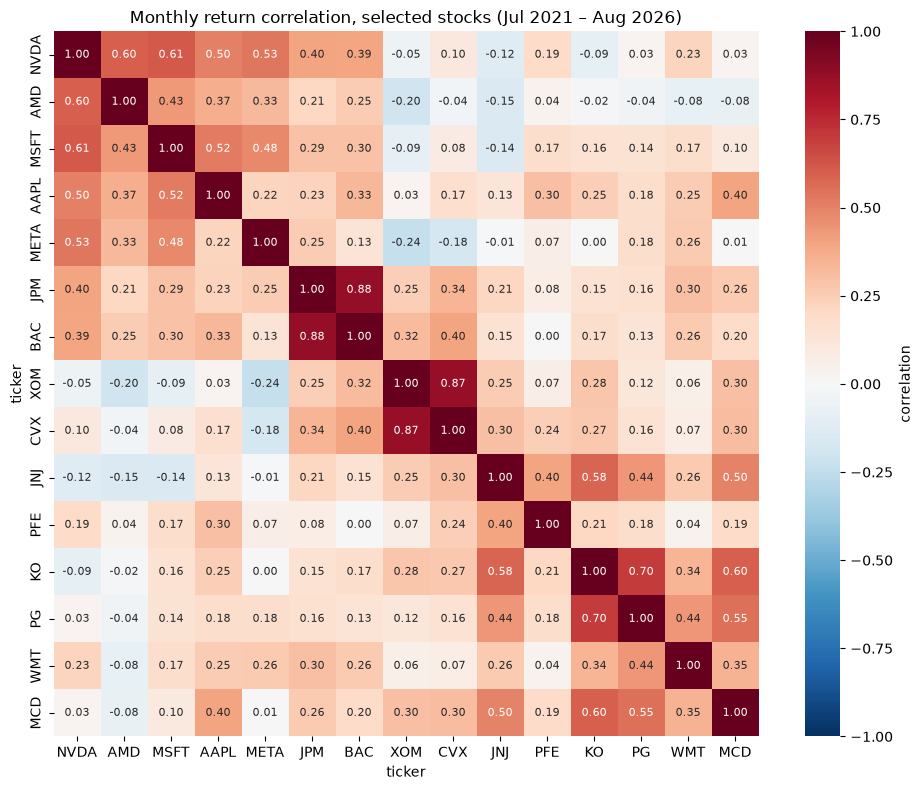

Average pairwise correlation, all 50 stocks: 0.24


In [9]:
SELECTED = ["NVDA", "AMD", "MSFT", "AAPL", "META",     # tech
            "JPM", "BAC",                              # banks
            "XOM", "CVX",                              # energy
            "JNJ", "PFE",                              # healthcare
            "KO", "PG", "WMT", "MCD"]                  # consumer staples / defensive
stock_corr = stock_m[SELECTED].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(stock_corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
            square=True, cbar_kws={"label": "correlation"}, annot_kws={"size": 8}, ax=ax)
ax.set_title("Monthly return correlation, selected stocks (Jul 2021 – Aug 2026)")
plt.tight_layout()
plt.savefig(f"{REPORTS}/stock_correlation_heatmap.png", dpi=150)
plt.show()

all_corr = stock_m.corr().values
n = len(all_corr)
print(f"Average pairwise correlation, all 50 stocks: {(all_corr.sum() - n) / (n * (n - 1)):.2f}")

### 2.3 Portfolio-level correlation matrix
The Week 2 factor portfolios, the equal-weight 50, and SPY. Saved to `reports/week3/portfolio_correlation.csv`.

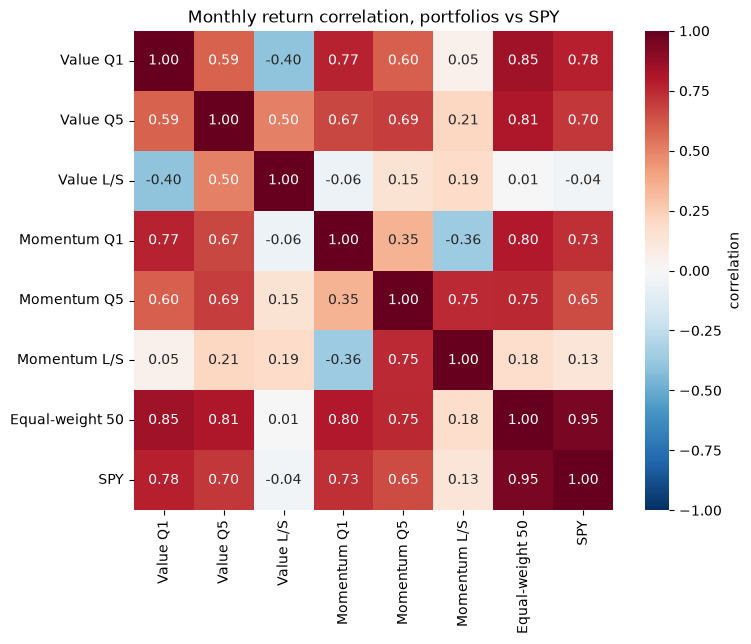

In [10]:
SAMPLE = pd.concat({
    "Value":    value_ret[["Q1", "Q5", "long_short"]],
    "Momentum": mom_ret[["Q1", "Q5", "long_short"]],
}, axis=1)
SAMPLE.columns = [f"{f} {q.replace('long_short', 'L/S')}" for f, q in SAMPLE.columns]
SAMPLE["Equal-weight 50"] = ew50_m

port_corr = SAMPLE.join(spy_m).corr()
port_corr.to_csv(f"{REPORTS}/portfolio_correlation.csv")

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(port_corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
            square=True, cbar_kws={"label": "correlation"}, ax=ax)
ax.set_title("Monthly return correlation, portfolios vs SPY")
plt.tight_layout()
plt.savefig(f"{REPORTS}/portfolio_correlation_heatmap.png", dpi=150)
plt.show()

### 2.4 Beta, tracking error and information ratio vs SPY
Same benchmark (SPY), same frequency (monthly), same dates for every portfolio. Saved to `reports/week3/benchmark_relative.csv`.

Tracking error and information ratio measure a long-only portfolio *against* SPY. A long–short is a zero-cost bet, not an alternative to SPY, so for it the useful numbers are beta, alpha and R².

**Flag:** a portfolio with beta of 0.8 or more and R² ≥ 0.5 moves mostly with the market (beta near one or above), however many names it holds. That is *market exposure in disguise*.

In [11]:
rel = benchmark_relative_metrics(SAMPLE, spy_m)
rel["n_stocks"] = [value_ret["n_Q1"].mean(), value_ret["n_Q5"].mean(), np.nan,
                   mom_ret["n_Q1"].mean(), mom_ret["n_Q5"].mean(), np.nan,
                   stock_m.notna().sum(axis=1).mean()]
rel["market_exposure_in_disguise"] = (rel["beta"] >= 0.8) & (rel["r2"] >= 0.5)
rel.to_csv(f"{REPORTS}/benchmark_relative.csv")

show = rel.copy()
for c in ["alpha_ann", "tracking_error", "active_return_ann"]:
    show[c] = (show[c] * 100).round(1)
show = show.rename(columns={"alpha_ann": "alpha_ann %", "tracking_error": "tracking_error %",
                            "active_return_ann": "active_return_ann %"})
show[["beta", "correlation", "r2", "information_ratio"]] = show[["beta", "correlation", "r2", "information_ratio"]].astype(float).round(2)
show["n_stocks"] = show["n_stocks"].round(0)
show.drop(columns=["periods_per_year"])

,beta,alpha_ann %,correlation,r2,tracking_error %,active_return_ann %,information_ratio,n_periods,n_stocks,market_exposure_in_disguise
Value Q1,1.41,2.9,0.78,0.61,18.9,8.5,0.45,62,9.0,True
Value Q5,1.35,23.3,0.70,0.49,22.0,28.1,1.28,62,9.0,False
Value L/S,-0.06,20.4,-0.04,0.00,31.2,5.7,0.18,62,NaN,False
Momentum Q1,1.27,13.1,0.73,0.53,19.2,16.9,0.88,62,10.0,True
Momentum Q5,1.59,27.3,0.65,0.42,30.6,35.5,1.16,62,10.0,False
Momentum L/S,0.32,14.2,0.13,0.02,39.7,4.8,0.12,62,NaN,False
Equal-weight 50,1.20,7.9,0.95,0.90,7.1,10.6,1.50,62,50.0,True


**Check:** beta recomputed by hand as the slope of an ordinary least-squares regression of the value long–short on SPY; and a deliberate frequency mismatch (monthly portfolio vs daily SPY) must be refused.

In [12]:
p = SAMPLE["Value L/S"]
X = np.column_stack([np.ones(len(spy_m)), spy_m.values])
ols_alpha, ols_beta = np.linalg.lstsq(X, p.values, rcond=None)[0]
print(f"Value L/S beta  code {rel.loc['Value L/S', 'beta']:.4f}  vs  OLS {ols_beta:.4f}")
print(f"Value L/S alpha code {rel.loc['Value L/S', 'alpha_ann']:.4f}  vs  OLS {ols_alpha * 12:.4f}")

spy_daily = spy.set_index("date")["adj_close"].pct_change().dropna()
try:
    align_to_benchmark(p, spy_daily)
except ValueError as e:
    print("Frequency mismatch refused:", e)

Value L/S beta  code -0.0613  vs  OLS -0.0613
Value L/S alpha code 0.2045  vs  OLS 0.2045
Frequency mismatch refused: frequency mismatch: portfolio 12/yr vs benchmark 252/yr


### 2.5 Diversification curve
For each portfolio size k, 500 random equal-weight portfolios of k stocks drawn from the stocks with a full history (RKLB is left out because its history starts in August 2021). The line is the average volatility, the band the 10th–90th percentile.

The dashed line is the theory for an equal-weight portfolio of k stocks:

  variance(k) = average variance / k + (1 − 1/k) × average covariance

As k grows the first term vanishes and volatility falls toward **√(average covariance)**, the floor set by how much the stocks move together. Saved to `reports/week3/diversification_curve.png`.

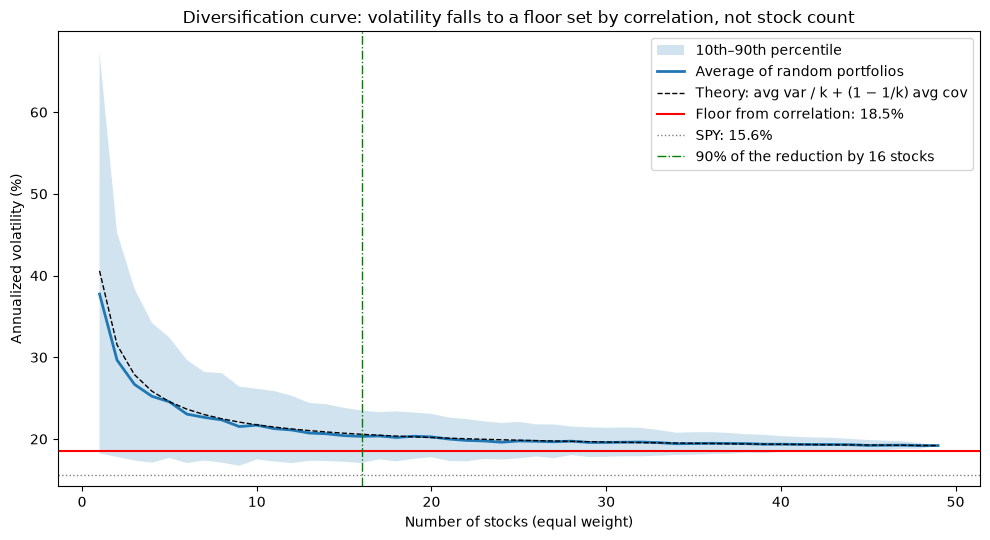

,value
Stocks in the universe,49
Average single-stock volatility,40.6%
Average pairwise correlation,0.24
Floor (√ average covariance),18.5%
"Average volatility, 5 stocks",24.6%
"Average volatility, 10 stocks",21.7%
"Average volatility, 20 stocks",20.3%
"Volatility, all 49 stocks",19.2%
Stocks needed for 90% of the reduction,16


In [13]:
curve = diversification_curve(stock_m, n_draws=500, seed=0)
a = curve.attrs
spy_vol = spy_m.std() * np.sqrt(12)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.fill_between(curve.index, curve["p10_vol"] * 100, curve["p90_vol"] * 100, alpha=0.2, label="10th–90th percentile")
ax.plot(curve.index, curve["avg_vol"] * 100, lw=2, label="Average of random portfolios")
ax.plot(curve.index, curve["theory_vol"] * 100, "k--", lw=1, label="Theory: avg var / k + (1 − 1/k) avg cov")
ax.axhline(a["floor_vol"] * 100, color="red", lw=1.5, label=f"Floor from correlation: {a['floor_vol']:.1%}")
ax.axhline(spy_vol * 100, color="gray", lw=1, ls=":", label=f"SPY: {spy_vol:.1%}")
ax.axvline(a["n_for_90pct"], color="green", lw=1, ls="-.", label=f"90% of the reduction by {a['n_for_90pct']} stocks")
ax.set_xlabel("Number of stocks (equal weight)")
ax.set_ylabel("Annualized volatility (%)")
ax.set_title("Diversification curve: volatility falls to a floor set by correlation, not stock count")
ax.legend()
plt.tight_layout()
plt.savefig(f"{REPORTS}/diversification_curve.png", dpi=150)
plt.show()

pd.DataFrame({
    "Stocks in the universe": a["n_universe"],
    "Average single-stock volatility": f"{a['avg_stock_vol']:.1%}",
    "Average pairwise correlation": f"{a['avg_pairwise_corr']:.2f}",
    "Floor (√ average covariance)": f"{a['floor_vol']:.1%}",
    f"Average volatility, 5 stocks": f"{curve.loc[5, 'avg_vol']:.1%}",
    f"Average volatility, 10 stocks": f"{curve.loc[10, 'avg_vol']:.1%}",
    f"Average volatility, 20 stocks": f"{curve.loc[20, 'avg_vol']:.1%}",
    f"Volatility, all {a['n_universe']} stocks": f"{curve['avg_vol'].iloc[-1]:.1%}",
    "Stocks needed for 90% of the reduction": a["n_for_90pct"],
}, index=["value"]).T

### 2.6 Key findings
Printed from the numbers above.

In [14]:
r = rel
print(f"1. Diversification: volatility falls from {a['avg_stock_vol']:.0%} (one stock) to "
      f"{curve.loc[10, 'avg_vol']:.0%} with 10 and {curve['avg_vol'].iloc[-1]:.0%} with all {a['n_universe']}. "
      f"90% of the fall is done by {a['n_for_90pct']} stocks; after that, an average correlation of "
      f"{a['avg_pairwise_corr']:.2f} holds volatility near the {a['floor_vol']:.0%} floor.")
disguised = r.index[r["market_exposure_in_disguise"]].tolist()
print(f"2. Market exposure in disguise (beta ≥ 0.8, R² ≥ 0.5): {', '.join(disguised) if disguised else 'none'}.")
for name in ["Equal-weight 50", "Value Q5", "Momentum Q5"]:
    print(f"   {name}: beta {r.loc[name, 'beta']:.2f}, R² {r.loc[name, 'r2']:.2f}, "
          f"tracking error {r.loc[name, 'tracking_error']:.1%}, information ratio {r.loc[name, 'information_ratio']:.2f}")
for name in ["Value L/S", "Momentum L/S"]:
    print(f"3. {name}: beta {r.loc[name, 'beta']:.2f}, R² {r.loc[name, 'r2']:.2f}, "
          f"alpha {r.loc[name, 'alpha_ann']:.1%} a year.")
print(f"4. Value L/S vs Momentum L/S correlation: {port_corr.loc['Value L/S', 'Momentum L/S']:.2f}.")

1. Diversification: volatility falls from 41% (one stock) to 22% with 10 and 19% with all 49. 90% of the fall is done by 16 stocks; after that, an average correlation of 0.24 holds volatility near the 18% floor.
2. Market exposure in disguise (beta ≥ 0.8, R² ≥ 0.5): Value Q1, Momentum Q1, Equal-weight 50.
   Equal-weight 50: beta 1.20, R² 0.90, tracking error 7.1%, information ratio 1.50
   Value Q5: beta 1.35, R² 0.49, tracking error 22.0%, information ratio 1.28
   Momentum Q5: beta 1.59, R² 0.42, tracking error 30.6%, information ratio 1.16
3. Value L/S: beta -0.06, R² 0.00, alpha 20.4% a year.
3. Momentum L/S: beta 0.32, R² 0.02, alpha 14.2% a year.
4. Value L/S vs Momentum L/S correlation: 0.19.


### 2.7 Notes
- **Same benchmark, same frequency:** beta, alpha, tracking error and information ratio are all measured against SPY on the same monthly month-end dates; `align_to_benchmark()` raises an error on a frequency mismatch (checked above).
- **Correlation sets the floor:** adding stocks removes the stock-specific part of risk only. The part they share (average covariance) stays, so the curve flattens at the floor however many names are added.
- **Count is not diversification:** a long-only portfolio of 10 or 50 stocks with a beta near one and a high R² is mostly SPY exposure: most of its swings come from the market, not from stock selection.
- **Long–short portfolios:** buying Q5 and selling Q1 cancels much of the market exposure, so beta and R² are the right test; tracking error vs SPY is not meaningful for a zero-cost portfolio.